In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# Load the customer dataset

file_path = "../data/customer_segmentation.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (2240, 29)


In [6]:
# Inspect the dataset

print("Dataset Information:")
df.info()

print("\nFirst 5 Rows:")
display(df.head())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 no

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
    # Check missing values and duplicate rows

print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Total Duplicate Rows:
0


In [8]:
# Fill missing Income values with the median income

median_income = df["Income"].median()

df["Income"] = df["Income"].fillna(median_income)

print("Median Income:", median_income)
print("\nMissing Income values after cleaning:")
print(df["Income"].isnull().sum())


Median Income: 51381.5

Missing Income values after cleaning:
0


Creating Customer Segmentation Features

In [9]:
# Create customer segmentation features

# Calculate age
df["Age"] = 2015 - df["Year_Birth"]

# Calculate total spending across product categories
df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

# Calculate total purchases across different channels
df["Total_Purchases"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

# Select features for clustering
segmentation_features = [
    "Age",
    "Income",
    "Total_Spending",
    "Total_Purchases"
]

print("Segmentation Features:")
print(segmentation_features)

display(df[segmentation_features].head())

Segmentation Features:
['Age', 'Income', 'Total_Spending', 'Total_Purchases']


,Age,Income,Total_Spending,Total_Purchases
0,58,58138.0,1617,22
1,61,46344.0,27,4
2,50,71613.0,776,20
3,31,26646.0,53,6
4,34,58293.0,422,14


In [10]:
# Check feature statistics before scaling

display(df[segmentation_features].describe())

,Age,Income,Total_Spending,Total_Purchases
count,2240.000000,2240.000000,2240.000000,2240.000000
mean,46.194196,52237.975446,605.798214,12.537054
std,11.984069,25037.955891,602.249288,7.205741
min,19.000000,1730.000000,5.000000,0.000000
25%,38.000000,35538.750000,68.750000,6.000000
50%,45.000000,51381.500000,396.000000,12.000000
75%,56.000000,68289.750000,1045.500000,18.000000
max,122.000000,666666.000000,2525.000000,32.000000


Scaling the Features

In [11]:
# Scale features using StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[segmentation_features])

print("Features scaled successfully.")
print("Scaled data shape:", X_scaled.shape)

Features scaled successfully.
Scaled data shape: (2240, 4)


Elbow Method to Choose k

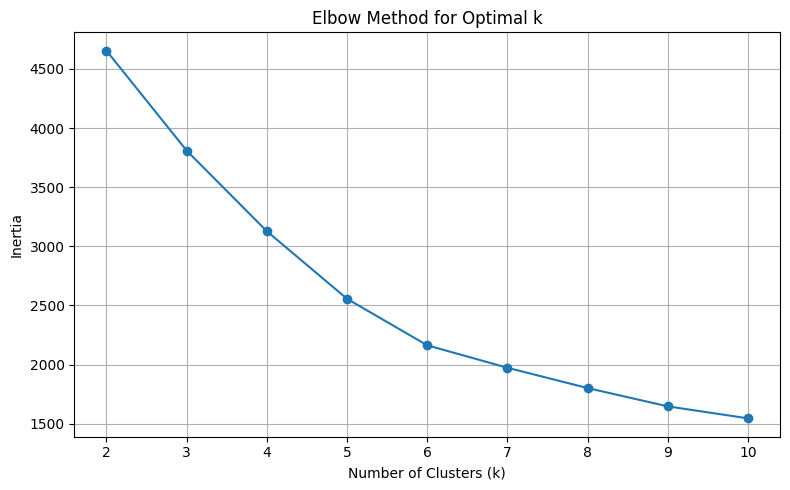

In [12]:
# Use the Elbow Method to find the optimal number of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(range(2, 11))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

From the graph, the inertia decreases sharply from k = 2 to k = 5, and after k = 5 the reduction becomes noticeably smaller.

So we'll use:

k = 5

This gives us 5 customer segments while keeping the model reasonably compact and interpretable.

Applying K-Means Clustering

In [13]:
# Apply K-Means clustering with the selected number of clusters

optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed successfully.")
print("\nCluster Distribution:")
print(df["Cluster"].value_counts().sort_index())

K-Means clustering completed successfully.

Cluster Distribution:
Cluster
0    480
1    760
2    475
3    524
4      1
Name: count, dtype: int64


Cluster	Customers
0	480
1	760
2	475
3	524
4	1

Having one customer alone in Cluster 4 is a strong sign that an extreme/outlier value is affecting the clustering. This is especially relevant because we saw earlier that Income has a maximum of 666,666, while the 75th percentile is only about 68,290.

Inspect the clusters

In [14]:
# Profile the initial K-Means clusters

cluster_profile = df.groupby("Cluster")[segmentation_features].agg(
    ["count", "mean", "min", "max"]
)

display(cluster_profile)

Age                     Income                                     \
        count       mean min  max  count           mean       min       max   
Cluster                                                                       
0         480  56.506250  42  122    480   43527.363542    4428.0  156924.0   
1         760  37.469737  19   52    760   32957.764474    1730.0   68274.0   
2         475  58.669474  48  116    475   69784.836842   33051.0  113734.0   
3         524  38.108779  20   49    524   71102.225191    2447.0  162397.0   
4           1  38.000000  38   38      1  666666.000000  666666.0  666666.0   

        Total_Spending                         Total_Purchases                 \
                 count         mean  min   max           count       mean min   
Cluster                                                                         
0                  480   199.591667    8   900             480   8.375000   0   
1                  760   114.415789    5   577             760   6.246053   0   
2                  475  1152.025263  277  2440             475  19.406316  10   
3                  524  1196.477099    6  2525             524  19.257634   0   
4                    1    62.000000   62    62               1   7.000000   7   

             
        max  
Cluster      
0        25  
1        16  
2        32  
3        32  
4         7

Inspect the Outlier Customer

In [15]:
# Inspect the customer with the highest income

outlier_customer = df.loc[df["Income"].idxmax()]

display(outlier_customer.to_frame(name="Value"))

,Value
ID,9432
Year_Birth,1977
Education,Graduation
Marital_Status,Together
Income,666666.0
Kidhome,1
Teenhome,0
Dt_Customer,02-06-2013
Recency,23
MntWines,9


Detect Income Outliers Using IQR

In [16]:
# Detect Income outliers using the IQR method

Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

income_outliers = df[
    (df["Income"] < lower_bound) |
    (df["Income"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Income Outliers:", len(income_outliers))

display(
    income_outliers[
        ["ID", "Age", "Income", "Total_Spending", "Total_Purchases"]
    ].sort_values("Income", ascending=False)
)

Q1: 35538.75
Q3: 68289.75
IQR: 32751.0

Lower Bound: -13587.75
Upper Bound: 117416.25

Number of Income Outliers: 8


,ID,Age,Income,Total_Spending,Total_Purchases
2233,9432,38,666666.0,62,7
617,1503,39,162397.0,107,1
687,1501,33,160803.0,1717,29
1300,5336,44,157733.0,59,2
164,8475,42,157243.0,1608,22
1653,4931,38,157146.0,1730,28
2132,11181,66,156924.0,8,0
655,5555,40,153924.0,6,0


Checkinng Age Outliers

In [17]:
# Detect Age outliers using the IQR method

Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df["Age"] < lower_age) |
    (df["Age"] > upper_age)
]

print("Age Q1:", Q1_age)
print("Age Q3:", Q3_age)
print("Age IQR:", IQR_age)

print("\nAge Lower Bound:", lower_age)
print("Age Upper Bound:", upper_age)

print("\nNumber of Age Outliers:", len(age_outliers))

display(
    age_outliers[
        ["ID", "Year_Birth", "Age", "Income", "Total_Spending"]
    ].sort_values("Age", ascending=False)
)

Age Q1: 38.0
Age Q3: 56.0
Age IQR: 18.0

Age Lower Bound: 11.0
Age Upper Bound: 83.0

Number of Age Outliers: 3


,ID,Year_Birth,Age,Income,Total_Spending
239,11004,1893,122,60182.0,22
339,1150,1899,116,83532.0,1853
192,7829,1900,115,36640.0,65


Removing the Clearly Anomalous Age Records

In [18]:
# Remove clearly anomalous age records

before_count = len(df)

df = df[df["Age"] <= 100].copy()

after_count = len(df)

print("Customers before removing age anomalies:", before_count)
print("Customers removed:", before_count - after_count)
print("Customers after cleaning:", after_count)

print("\nMaximum age after cleaning:", df["Age"].max())

Customers before removing age anomalies: 2240
Customers removed: 3
Customers after cleaning: 2237

Maximum age after cleaning: 75


Cap Extreme Income Values

In [20]:
# Cap extreme Income values using the IQR upper bound

income_upper_bound = upper_bound

df["Income"] = df["Income"].clip(upper=income_upper_bound)

print("Income values capped at:", income_upper_bound)
print("Maximum Income after capping:", df["Income"].max())
print("Customers remaining:", len(df))

Income values capped at: 117416.25
Maximum Income after capping: 117416.25
Customers remaining: 2237


Recreate Segmentation Features

In [21]:
# Recreate segmentation features after cleaning

segmentation_features = [
    "Age",
    "Income",
    "Total_Spending",
    "Total_Purchases"
]

X = df[segmentation_features].copy()

print("Segmentation data shape:", X.shape)
display(X.head())

Segmentation data shape: (2237, 4)


,Age,Income,Total_Spending,Total_Purchases
0,58,58138.0,1617,22
1,61,46344.0,27,4
2,50,71613.0,776,20
3,31,26646.0,53,6
4,34,58293.0,422,14


Scale the Cleaned Features Again

In [22]:
# Scale the cleaned segmentation features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Cleaned features scaled successfully.")
print("Scaled data shape:", X_scaled.shape)

Cleaned features scaled successfully.
Scaled data shape: (2237, 4)


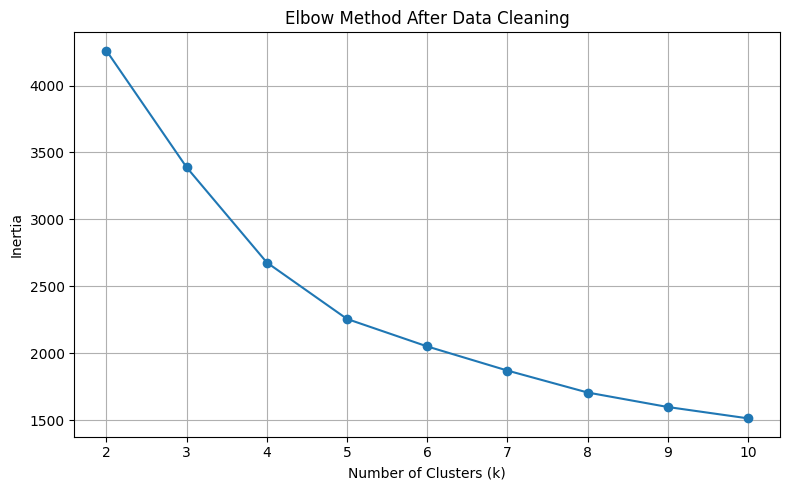

In [23]:
# Re-run the Elbow Method on cleaned data

inertia = []

for k in range(2, 11):
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans_test.fit(X_scaled)
    inertia.append(kmeans_test.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method After Data Cleaning")
plt.xticks(range(2, 11))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/elbow_method_cleaned.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The inertia drops substantially from:

k = 2 → 3 → 4 → 5

After k = 5, the curve becomes considerably flatter, so the elbow is around 5.

Therefore, we'll use:

optimal_k = 5

Apply the Final K-Means Model

In [24]:
# Apply final K-Means clustering

optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Final K-Means clustering completed.")
print("\nCluster Distribution:")
print(df["Cluster"].value_counts().sort_index())

Final K-Means clustering completed.

Cluster Distribution:
Cluster
0    384
1    665
2    344
3    421
4    423
Name: count, dtype: int64


Create Cluster Visualization

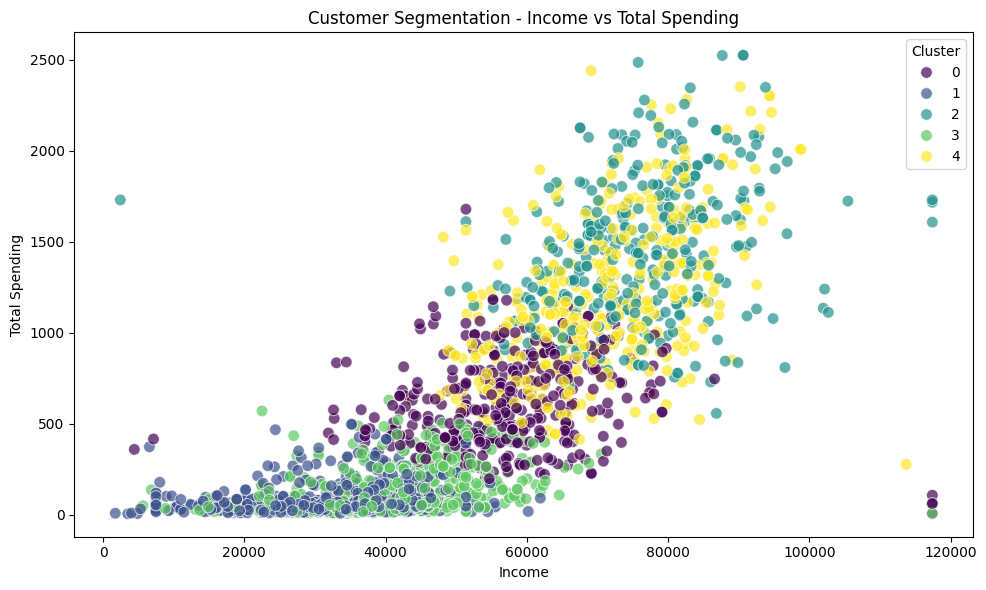

In [25]:
# Visualize customer clusters

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Cluster",
    palette="viridis",
    s=70,
    alpha=0.7
)

plt.title("Customer Segmentation - Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "../outputs/customer_clusters_income_spending.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Visualize Age vs Total Spending

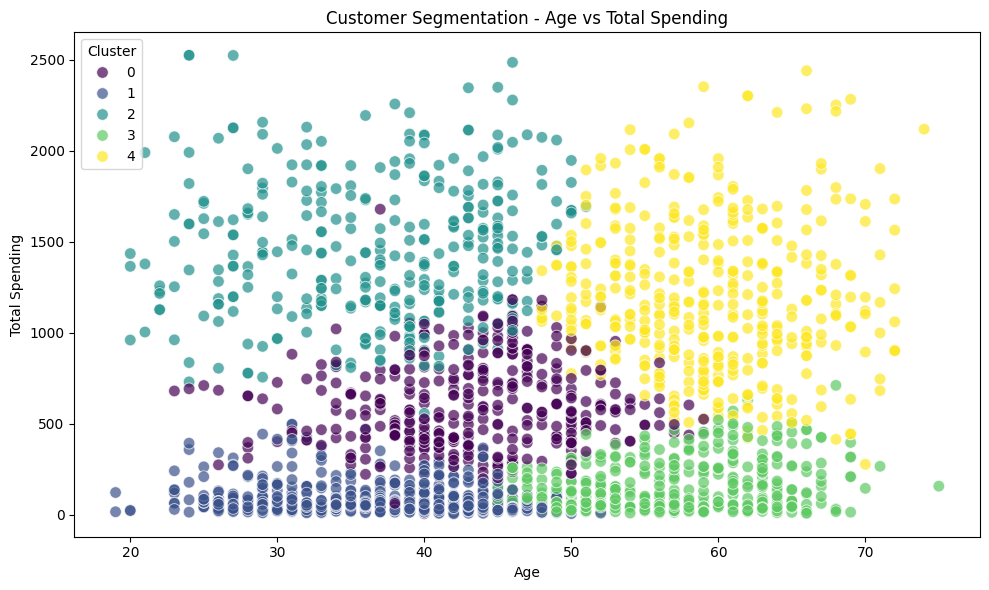

In [26]:
# Visualize customer clusters using Age and Total Spending

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total_Spending",
    hue="Cluster",
    palette="viridis",
    s=70,
    alpha=0.7
)

plt.title("Customer Segmentation - Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "../outputs/customer_clusters_age_spending.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Create the Cluster Profile

In [28]:
# Create a profile for each customer cluster

cluster_profile = df.groupby("Cluster")[segmentation_features].mean().round(2)

# Add number of customers in each cluster
cluster_profile["Customer_Count"] = df["Cluster"].value_counts().sort_index()

display(cluster_profile)

,Age,Income,Total_Spending,Total_Purchases,Customer_Count
Cluster,,,,,
0,43.22,57046.28,604.15,15.52,384
1,37.07,30821.98,83.59,5.51,665
2,36.93,75850.93,1453.95,20.52,344
3,57.01,41719.94,158.83,7.37,421
4,59.51,70780.15,1183.08,19.57,423


Create Segment Names

In [29]:
# Assign meaningful names to the customer segments

cluster_names = {
    0: "Moderate Income - Moderate Spenders",
    1: "Low Income - Low Spenders",
    2: "High Income - High Spenders",
    3: "Older - Low Spenders",
    4: "Older - High Spenders"
}

df["Segment"] = df["Cluster"].map(cluster_names)

# Display segment distribution
segment_distribution = (
    df["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customer_Count")
)

display(segment_distribution)

,Segment,Customer_Count
0,Low Income - Low Spenders,665
1,Older - High Spenders,423
2,Older - Low Spenders,421
3,Moderate Income - Moderate Spenders,384
4,High Income - High Spenders,344


Create the Detailed Segment Report

In [30]:
# Create a detailed customer segment report

segment_report = df.groupby("Segment").agg(
    Customer_Count=("ID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Income", "mean"),
    Average_Spending=("Total_Spending", "mean"),
    Average_Purchases=("Total_Purchases", "mean")
).round(2)

display(segment_report)

,Customer_Count,Average_Age,Average_Income,Average_Spending,Average_Purchases
Segment,,,,,
High Income - High Spenders,344,36.93,75850.93,1453.95,20.52
Low Income - Low Spenders,665,37.07,30821.98,83.59,5.51
Moderate Income - Moderate Spenders,384,43.22,57046.28,604.15,15.52
Older - High Spenders,423,59.51,70780.15,1183.08,19.57
Older - Low Spenders,421,57.01,41719.94,158.83,7.37


Add Marketing Actions

In [31]:
# Add suggested marketing actions for each customer segment

marketing_actions = {
    "High Income - High Spenders":
        "Offer premium products, loyalty rewards, and personalized premium offers.",

    "Low Income - Low Spenders":
        "Use budget-friendly offers, discounts, and low-cost product recommendations.",

    "Moderate Income - Moderate Spenders":
        "Use personalized recommendations, bundle offers, and loyalty incentives.",

    "Older - High Spenders":
        "Promote premium products, loyalty benefits, and personalized offers suitable for mature customers.",

    "Older - Low Spenders":
        "Use simple promotional offers, targeted discounts, and product recommendations to encourage engagement."
}

segment_report["Marketing_Action"] = segment_report.index.map(marketing_actions)

display(segment_report)

,Customer_Count,Average_Age,Average_Income,Average_Spending,Average_Purchases,Marketing_Action
Segment,,,,,,
High Income - High Spenders,344,36.93,75850.93,1453.95,20.52,"Offer premium products, loyalty rewards, and p..."
Low Income - Low Spenders,665,37.07,30821.98,83.59,5.51,"Use budget-friendly offers, discounts, and low..."
Moderate Income - Moderate Spenders,384,43.22,57046.28,604.15,15.52,"Use personalized recommendations, bundle offer..."
Older - High Spenders,423,59.51,70780.15,1183.08,19.57,"Promote premium products, loyalty benefits, an..."
Older - Low Spenders,421,57.01,41719.94,158.83,7.37,"Use simple promotional offers, targeted discou..."


In [32]:
# Save the customer segment report

segment_report.to_csv(
    "../outputs/customer_segment_report.csv"
)

print("Customer segment report saved successfully.")
print("Saved at: ../outputs/customer_segment_report.csv")

Customer segment report saved successfully.
Saved at: ../outputs/customer_segment_report.csv


Save Customer-Level Cluster Labels

In [33]:
# Save customer data with cluster labels

clustered_data_path = "../outputs/customer_segments.csv"

df.to_csv(
    clustered_data_path,
    index=False
)

print("Customer segmentation results saved successfully.")
print("Saved at:", clustered_data_path)
print("Number of customers:", len(df))

Customer segmentation results saved successfully.
Saved at: ../outputs/customer_segments.csv
Number of customers: 2237


Visualize Customer Count by Segment

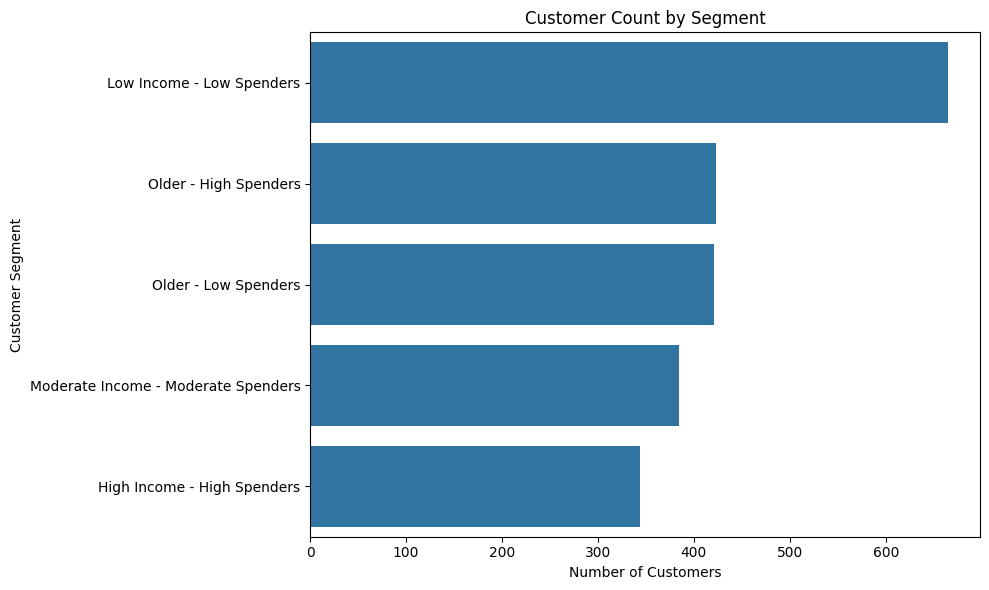

In [34]:
# Visualize the number of customers in each segment

segment_counts = df["Segment"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.title("Customer Count by Segment")

plt.tight_layout()

plt.savefig(
    "../outputs/customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save the K-Means Model and Scaler

In [35]:
# Save the trained K-Means model and scaler

import joblib

kmeans_model_path = "../models/customer_segmentation_kmeans.pkl"
scaler_path = "../models/customer_segmentation_scaler.pkl"

joblib.dump(kmeans, kmeans_model_path)
joblib.dump(scaler, scaler_path)

print("K-Means model saved at:")
print(kmeans_model_path)

print("\nScaler saved at:")
print(scaler_path)

K-Means model saved at:
../models/customer_segmentation_kmeans.pkl

Scaler saved at:
../models/customer_segmentation_scaler.pkl


Test the Saved Model

In [36]:
# Test the saved K-Means model and scaler

loaded_kmeans = joblib.load(
    "../models/customer_segmentation_kmeans.pkl"
)

loaded_scaler = joblib.load(
    "../models/customer_segmentation_scaler.pkl"
)

# Take one existing customer as a test example
test_customer = df[segmentation_features].iloc[[0]]

# Scale the customer's features
test_customer_scaled = loaded_scaler.transform(test_customer)

# Predict the cluster
predicted_cluster = loaded_kmeans.predict(test_customer_scaled)[0]

# Convert cluster number to segment name
predicted_segment = cluster_names[predicted_cluster]

print("Test Customer:")
display(test_customer)

print("\nPredicted Cluster:", predicted_cluster)
print("Predicted Segment:", predicted_segment)

Test Customer:


,Age,Income,Total_Spending,Total_Purchases
0,58,58138.0,1617,22



Predicted Cluster: 4
Predicted Segment: Older - High Spenders
